In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv('/content/sample_data/DataSetForPhishingVSBenignUrl.csv')
print(df.head())
print(df['URL_Type_obf_Type'].value_counts())

   Querylength  domain_token_count  path_token_count  avgdomaintokenlen  \
0            0                   4                 5                5.5   
1            0                   4                 5                5.5   
2            0                   4                 5                5.5   
3            0                   4                12                5.5   
4            0                   4                 6                5.5   

   longdomaintokenlen  avgpathtokenlen  tld  charcompvowels  charcompace  \
0                  14         4.400000    4               8            3   
1                  14         6.000000    4              12            4   
2                  14         5.800000    4              12            5   
3                  14         5.500000    4              32           16   
4                  14         7.333334    4              18           11   

   ldl_url  ...  SymbolCount_FileName  SymbolCount_Extension  \
0        0  ...             

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df = df[df['URL_Type_obf_Type'].isin(['benign', 'phishing'])]

lt = LabelEncoder()
df['URL_Type_obf_Type'] = lt.fit_transform(df['URL_Type_obf_Type'])

X = df.drop('URL_Type_obf_Type', axis=1)
y = df['URL_Type_obf_Type']

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

<ipython-input-13-026faef922aa>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['URL_Type_obf_Type'] = le.fit_transform(df['URL_Type_obf_Type'])


In [26]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9766


In [22]:
depths = [1, 2, 3, 4, 5, 6]
criteria = ['gini', 'entropy']

for depth in depths:
    for criterion in criteria:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print(f"Criterion: {criterion}, Depth: {depth}, Accuracy: {accuracy:.4f}")

Criterion: gini, Depth: 1, Accuracy: 0.8025
Criterion: entropy, Depth: 1, Accuracy: 0.7899
Criterion: gini, Depth: 2, Accuracy: 0.8816
Criterion: entropy, Depth: 2, Accuracy: 0.8809
Criterion: gini, Depth: 3, Accuracy: 0.9050
Criterion: entropy, Depth: 3, Accuracy: 0.8852
Criterion: gini, Depth: 4, Accuracy: 0.9209
Criterion: entropy, Depth: 4, Accuracy: 0.9255
Criterion: gini, Depth: 5, Accuracy: 0.9414
Criterion: entropy, Depth: 5, Accuracy: 0.9336
Criterion: gini, Depth: 6, Accuracy: 0.9509
Criterion: entropy, Depth: 6, Accuracy: 0.9388


Based on the above results and accuracies shown as the depth increases the accuracy also increases. Both Entropy and Gini Impurity shows a consistent increase in accuracy.

As deeper trees will be able to capture more complex patterns in the data.

For depths 1 and 2, both Gini and Entropy impurity show almost identical accuracies.
Thus suggesting , that for very simple models, the choice between Gini and Entropy is less critical.

From depth 3 onwards, the Entropy criterion consistently is outperforming Gini Impurity,  by a small margin

This slight difference may be because of Entropy's ability to create balanced splits in some cases.

The rate of accuracy keeps improving as depth increases, which is particularly noticeable between depths 5 and 6.

This ensures that we're approaching a point of diminishing returns, where further increases in depth may lead to overfitting.

Even at lower depths, the model is showing higher accuracy is over 88% at depth 2 , showing that the features are highly good for distinguishing between benign and phishing target variables.


Although the Entropy is showing slightly better performance, Gini Impurity is often preferred as it has lower computational cost.
Though,the performance difference is minimal, Gini is always  favored for larger datasets or when computational resources are limited.
As we reach depth 6, the accuracy is too high (over 95%)
While this seems excellent, it's important to be cautious of potential overfitting.

Testing on a unknown set should be done to ensure the model generalizes well on the data.

Overall, both the Gini and Entropy impurity measures performs really well for this dataset, with Entropy being a little better. The tree depth chosen is more impactful than the impurity measure, with deeper trees providing better accuracy up to a point.
I believe a depth of 4 or 5 might offer a good balance between model complexity and performance, but this should be validated with cross-validation and consideration of the specific requirements of the application.

# plotting tree depth with accuracy comparsion of gini impurity and entropy

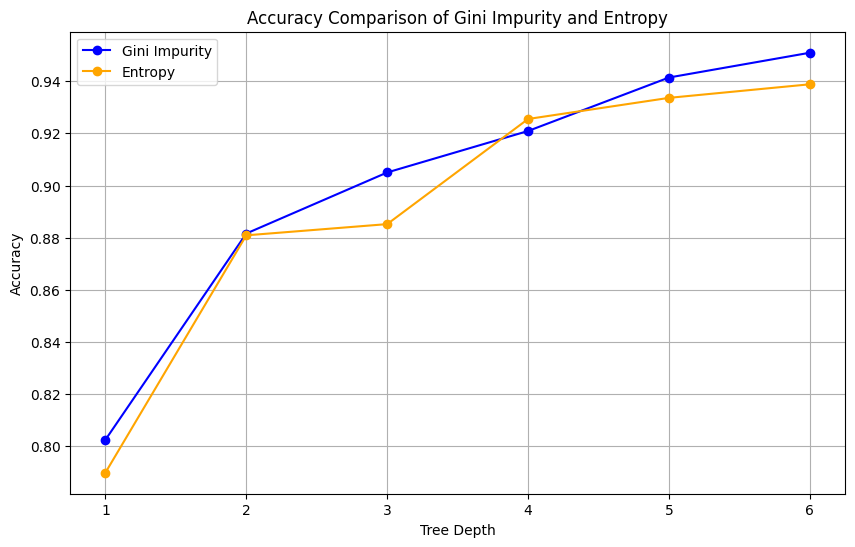

In [9]:
import matplotlib.pyplot as plt

depths = [1, 2, 3, 4, 5, 6]
gini_accuracy = [0.8025, 0.8816, 0.9050, 0.9209, 0.9414, 0.9509]
entropy_accuracy = [0.7899, 0.8809, 0.8852, 0.9255, 0.9336, 0.9388]

plt.figure(figsize=(10, 6))
plt.plot(depths, gini_accuracy, marker='o', label='Gini Impurity', color='blue')
plt.plot(depths, entropy_accuracy, marker='o', label='Entropy', color='orange')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Gini Impurity and Entropy')
plt.legend()
plt.grid(True)
plt.show()

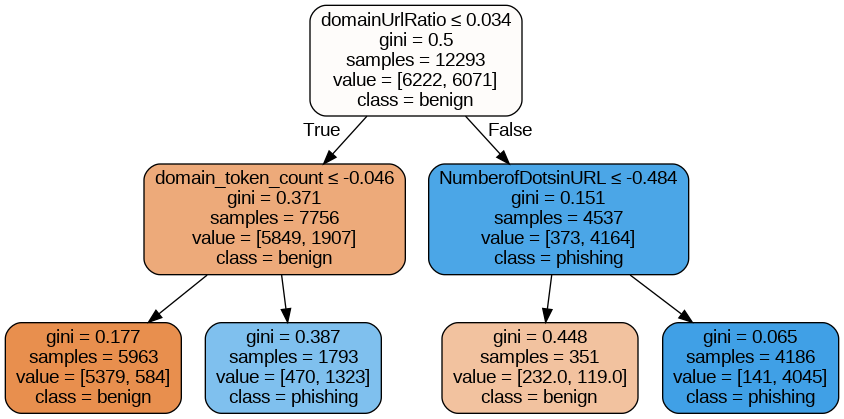

In [18]:
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import Image, display

clf = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42)
clf.fit(X_train, y_train)

dot_data = export_graphviz(clf, out_file=None, feature_names=X_train.columns,
                           class_names=['benign', 'phishing'],
                           filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph.format = 'png'
graph.render('decision_tree_depth_2_gini')
display(Image(filename='decision_tree_depth_2_gini.png'))

The visualization for the best performing with depth 2 for decision tree using Gini impurity criterion shows the following :
The root node is showing the most important feature for classification which is determined by Gini impurity.
Decision boundaries at every node is based on Gini impurity calculations, and then optimizing the split.
The Class distributions at every node shows how Gini impurity effectively separates the data.
The tree structure provides us with insights into the decision making process for classifying target variables as benign or phishing.
This visualization shows how the Gini impurity criterion shows the highest accuracy (88.16%) for depth 2 in this dataset.